# Red Pill: Una Red Neuronal desde Cero con NumPy puro

> *"Después de esto, no hay vuelta atrás. Tomas la pastilla azul… la historia termina.*
> *Tomas la roja… te quedas en el país de las maravillas y te enseño qué tan profundo llega la madriguera."* — Morpheus

Este notebook construye una **red neuronal (MLP) completa a mano**: capa densa, ReLU, softmax, cross-entropy y **backpropagation manual**.
Sin TensorFlow, sin Keras, sin PyTorch, sin autograd, sin `.fit()`. Solo `NumPy`, `Matplotlib` y la regla de la cadena.

**Importante:** este notebook viene **comentado línea a línea** para estudiar. Borrá los comentarios a medida que
los vayas entendiendo: ese es el momento en que la idea pasa a ser tuya.

**Dataset:** MNIST (60.000 dígitos escritos a mano de entrenamiento + 10.000 de test).
**Red:** 784 (píxeles) → 128 (ReLU) → 64 (ReLU) → 10 (logits).

---

## Plan del notebook

| Sección | Qué pasa |
|---|---|
| 1. Carga y exploración | Bajamos MNIST en formato IDX y lo parseamos a mano |
| 2. Implementación | `DenseLayer`, `ReLU`, `Softmax`, `CrossEntropyLoss` desde cero |
| 2.5. Gradient check | Verificamos que el backprop manual es correcto contra derivadas numéricas |
| 3. Entrenamiento | Backprop manual, update de pesos, curvas por epoch, guardado del mejor modelo, early stopping y chequeo de neuronas muertas |
| 4. Evaluación | Accuracy en test, predicciones buenas/malas, matriz de confusión |
| 5. Conclusiones | La celda obligatoria: qué entendiste que antes no entendías |

---

---

# 1. Carga y exploración del dataset

Sin frameworks, MNIST hay que **bajarlo y parsearlo a mano**. El formato clásico son 4 archivos `IDX`:
un magic number de 4 bytes, las dimensiones, y los datos crudos. Un problema *perfecto* para leer con `np.frombuffer`.

Descargamos directamente los archivos del mirror oficial de PyTorch (`ossci-datasets.s3.amazonaws.com/mnist`),
los descomprimimos con `gzip` del stdlib y los volcamos a arrays de NumPy. Cero dependencias extra.

In [1]:
import gzip                # descomprime los archivos .gz de MNIST    
from pathlib import Path   

import numpy as np              
import matplotlib.pyplot as plt 

%matplotlib inline
# Config. para que los graficos sean mas claros
plt.rcParams["figure.dpi"] = 110          
plt.rcParams["axes.spines.top"] = False   
plt.rcParams["axes.spines.right"] = False 
plt.rcParams["figure.max_open_warning"] = 0  

# Detecc. de la ubicacion (raiz del repo o /notebooks)
ROOT = Path.cwd()
if ROOT.name == "notebooks":   
    ROOT = ROOT.parent         
DATA_DIR = ROOT / "data" / "mnist"      # carpeta de los .gz descargados
FIG_DIR = ROOT / "results" / "figures"  # carpeta de los plots
FIG_DIR.mkdir(parents=True, exist_ok=True)  
print("Raíz del repo:", ROOT)

Raíz del repo: C:\Users\kathe\OneDrive\Desktop\C5DS - Neural_Numpy


In [2]:
# Decarga y Parseo del Formato IDX

MNIST_URL = "https://ossci-datasets.s3.amazonaws.com/mnist/"  # mirror oficial de PyTorch

FILES = {                 
    "train_images": "train-images-idx3-ubyte.gz",  # 60k imágenes 28x28
    "train_labels": "train-labels-idx1-ubyte.gz",  # 60k etiquetas (0-9)
    "test_images":  "t10k-images-idx3-ubyte.gz",   # 10k imágenes
    "test_labels":  "t10k-labels-idx1-ubyte.gz",   # 10k etiquetas
}

def download_mnist():
    DATA_DIR.mkdir(parents=True, exist_ok=True)   
    for name, fname in FILES.items():             
        dest = DATA_DIR / fname             

        if not dest.exists():                     
            print(f"Descargando {fname} ...")
            urllib.request.urlretrieve(MNIST_URL + fname, dest)  # descarga de c/ arch.
        else:                                 
            print(f"{fname} ya está en disco.")

def parse_idx(path: Path):
    # Parsea de archivo IDX a array de NumPy

    with gzip.open(path, "rb") as f:   # abre el arch. en modo lect. binaria
        raw = bytearray(f.read()) 

    magic = int.from_bytes(raw[0:4], "big")        # ident. el tipo de dato: 2051 -> imag., 2049 -> etiq.
    ndim = magic & 0xFF                            # extr. ult. byte para ndim (1 o 3)
    dims = [int.from_bytes(raw[4 + 4 * i: 8 + 4 * i], "big") for i in range(ndim)]  # lect. del tam. de cada dim.
    data = np.frombuffer(raw, dtype=np.uint8, offset=4 + 4 * ndim)  # de array binario a array Numpy
    return data.reshape(dims) # tensor org. segun las dim.                     


download_mnist()  # descarga
train_images = parse_idx(DATA_DIR / FILES["train_images"])       
train_labels = parse_idx(DATA_DIR / FILES["train_labels"]).astype(np.int64)
test_images  = parse_idx(DATA_DIR / FILES["test_images"])       
test_labels  = parse_idx(DATA_DIR / FILES["test_labels"]).astype(np.int64)  

print("train_images:", train_images.shape, train_images.dtype)
print("train_labels:", train_labels.shape, train_labels.dtype)
print("test_images :", test_images.shape, test_images.dtype)
print("test_labels :", test_labels.shape, test_labels.dtype)
print("\nEtiquetas únicas en train:", np.unique(train_labels))

train-images-idx3-ubyte.gz ya está en disco.
train-labels-idx1-ubyte.gz ya está en disco.
t10k-images-idx3-ubyte.gz ya está en disco.
t10k-labels-idx1-ubyte.gz ya está en disco.


train_images: (60000, 28, 28) uint8
train_labels: (60000,) int64
test_images : (10000, 28, 28) uint8
test_labels : (10000,) int64

Etiquetas únicas en train: [0 1 2 3 4 5 6 7 8 9]


In [3]:
# Preprocesamiento

# Aplanamiento (28x28 a 784) y Normalizacion (0 a 1)  
X = train_images.reshape(train_images.shape[0], -1).astype(np.float64) / 255.0
X_test = test_images.reshape(test_images.shape[0], -1).astype(np.float64) / 255.0

# One hot (vector de 10 posic.)
Y     = np.eye(10)[train_labels]   
Y_test = np.eye(10)[test_labels]

print("X       :", X.shape, "| valores en [%.1f, %.1f]" % (X.min(), X.max()))
print("Y       :", Y.shape, "(one-hot)")
print("X_test  :", X_test.shape)
print("Y_test  :", Y_test.shape)

# Subcojunto de valid. (ult. 5k)
X_train, Y_train = X[:55000], Y[:55000]   
y_train = train_labels[:55000]            # form. original
X_val, Y_val = X[55000:], Y[55000:]      
y_val  = train_labels[55000:]
print("\nsplit train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

X       : (60000, 784) | valores en [0.0, 1.0]
Y       : (60000, 10) (one-hot)
X_test  : (10000, 784)
Y_test  : (10000, 10)

split train: (55000, 784) | val: (5000, 784) | test: (10000, 784)


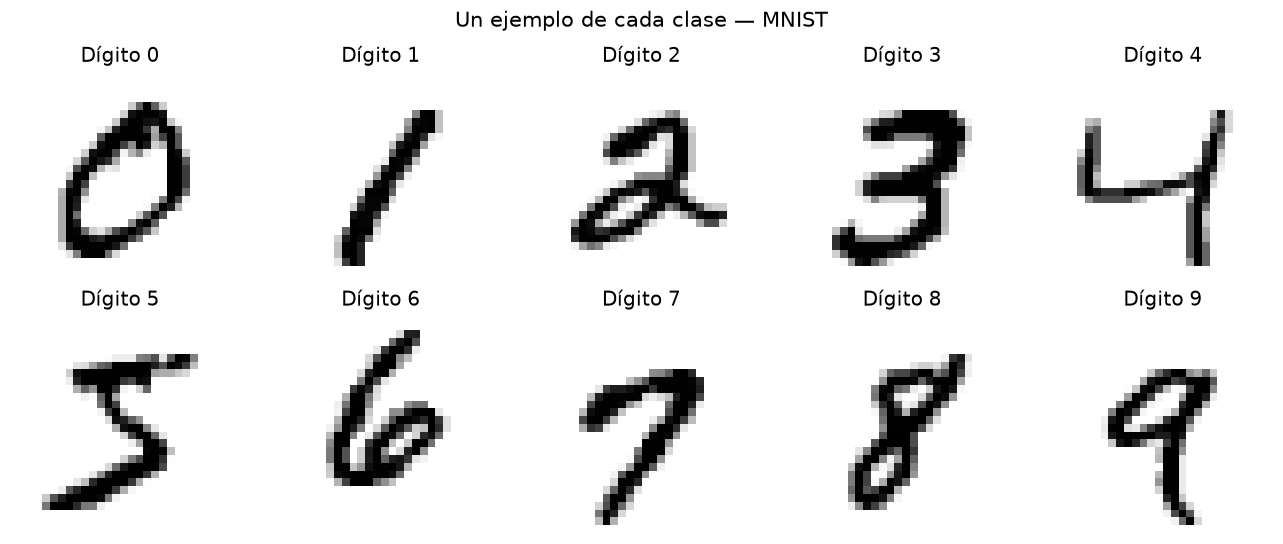

Conteos por clase (train): {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


In [4]:
# Vistazo rapido a los datos

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):                    
    idx = np.where(train_labels == digit)[0][0]  # primer ejemplo de ese dígito
    ax = axes[digit // 5, digit % 5]       
    ax.imshow(train_images[idx], cmap="gray_r")  # la imagen 28x28 (invertida)
    ax.set_title(f"Dígito {digit}", fontsize=13)
    ax.axis("off")                         
fig.suptitle("Un ejemplo de cada clase — MNIST", fontsize=14)
plt.tight_layout()                         
plt.savefig(FIG_DIR / "ejemplos_por_clase.png", dpi=130, bbox_inches="tight")
plt.show()

# Distribución de clases
clases, conteos = np.unique(train_labels, return_counts=True)
print("Conteos por clase (train):", dict(zip(clases.tolist(), conteos.tolist())))

---

# 2. Implementación desde cero

## 2.1. Capa densa (`Dense`)

Una capa densa hace exactamente una cosa: **una transformación lineal**. Dada una entrada $h^{in}$, produce

$$
z = W^T h^{in} + b
$$

y en forma matricial (con un *batch* completo $H$ de $B$ muestras):

$$
Z = H \, W + b \qquad W \in \mathbb{R}^{\,n_{in} \times n_{out}}, \quad b \in \mathbb{R}^{\,n_{out}}
$$

- $W$ son los **pesos** (lo que la red aprende). Se inicializan con *He initialization*:
  $W \sim \mathcal{N}\left(0, \sqrt{2/n_{in}}\right)$, pensada para activaciones ReLU: si la entrada tiene varianza acotada,
  la salida también la tiene, y el gradiente no explota ni se desvanece en las primeras capas.
- $b$ es el **bias**, inicializado en cero.

Cada capa guarda su entrada $x$ durante el *forward* y calcula los gradientes $\partial L / \partial W$ y $\partial L / \partial b$
durante el *backward*.

In [5]:
class DenseLayer:
    def __init__(self, n_in: int, # entrada 
                 n_out: int,  # salida 
                 seed: int = 0,  # reproducibilidad
                 init: str = "he"): # inic. de pesos
        
        rng = np.random.default_rng(seed) # generad. de num. aleat.

        std = np.sqrt(2.0 / n_in) if init == "he" else np.sqrt(1.0 / n_in) # std de los pesos segun el inic.

        self.W = rng.normal(0.0, std, size=(n_in, n_out)) # matriz de pesos (entradas, neuronas)
        
        self.b = np.zeros(n_out) # inic. de sesgos en cero
        self.x = None # entrada
        
        # Gradientes calc. en backward
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x                       # entrada para el calc. del backward
        return x @ self.W + self.b       # mult. matrices y sum. el sesgo

    def backward(self, dout): # Calc. y acum. de grad.
        self.dW = self.x.T @ dout        # grad. pesos = X^T · dL/dz   (n_in, n_out) = dim. W
        self.db = dout.sum(axis=0)       # grad. sesgos = sum. de los errores del batch (n_out,) = dim. b
        return dout @ self.W.T           # grad. perd./entrada = dL/dz · W^T -> lo dev. a la capa ant., para que haga su propio calc.

    #   Repr. del obj. si lo imprimimos (ent. -> sal.)
    def __repr__(self):
        return "DenseLayer({} -> {})".format(self.W.shape[0], self.W.shape[1])

##  2.2. Funcion de Activacion ReLU

La activación más simple y brutal que existe:

$$
\text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{si } x > 0 \\ 0 & \text{si } x \le 0 \end{cases}
\qquad
\text{ReLU}'(x) = \begin{cases} 1 & \text{si } x > 0 \\ 0 & \text{si } x \le 0 \end{cases}
$$

La derivada es **1** donde la neurona "está activa" y **0** donde está apagada. Eso significa que en el backward,
la ReLU simplemente *apaga* esas neuronas: no dejan pasar gradiente. Simple y efectivo.

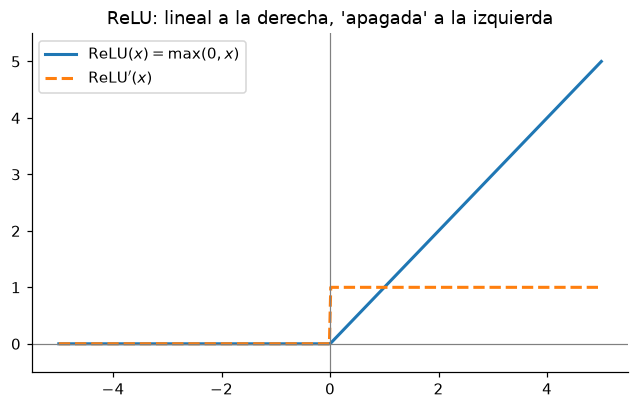

In [6]:
class ReLU:
    def forward(self, x):
        self.x = x                       # entrada para preserv. valores +
        return np.maximum(x, 0.0)        # todo lo negativo pasa a 0

    
    def backward(self, dout): 
        return dout * (self.x > 0)       # matriz bool. para + y -

    def __repr__(self):
        return "ReLU()"

# Visual. de ReLU y su derivada

x = np.linspace(-5, 5, 400)     # vector de 400 puntos entre -5 y 5
relu = np.maximum(x, 0.0)       
drelu = (x > 0).astype(float)   

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, relu, lw=2, label=r"ReLU$(x) = \max(0, x)$")   # línea sólida
ax.plot(x, drelu, lw=2, ls="--", label=r"ReLU$'(x)$")     # línea punteada
ax.axhline(0, color="gray", lw=0.8)    # eje x
ax.axvline(0, color="gray", lw=0.8)    # eje y
ax.set_ylim(-0.5, 5.5)
ax.set_title("ReLU: lineal a la derecha, 'apagada' a la izquierda")
ax.legend()
plt.savefig(FIG_DIR / "relu.png", dpi=130, bbox_inches="tight")
plt.show()

## 2.3. Softmax y Cross-entropy

La última capa emite **logits** $z_1, \dots, z_{10}$ (números reales sin acotar). Los convertimos en una **distribución
de probabilidad** con softmax:

$$
p_k = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}}
\qquad\Rightarrow\qquad 0 < p_k < 1,\quad \sum_k p_k = 1
$$

> ⚠️ **Estabilidad numérica:** en vez de calcular $e^{z_k}$ directo, restamos el máximo: $e^{z_k - \max z}$.
> El resultado es matemáticamente idéntico, pero evita overflow ($e^{1000}$ no cabe en un float).

La **cross-entropy** compara la distribución predicha $p$ con la real $y$ (one-hot):

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{10} y_{ik} \log p_{ik}
$$

Como $y$ es one-hot, solo sobrevive el término de la clase correcta: el logaritmo castiga fuerte cuando la red
le da poca probabilidad a la clase correcta. **Si $p_{correcta} \to 1$, la pérdida tiende a 0; si la clase correcta
tiene probabilidad baja, la pérdida explota.**

### El truco estrella: dL/dz para softmax + cross-entropy

Derivar softmax es un suplicio (matriz jacobiana, denominador compartido…). Pero si la pérdida es cross-entropy,
todo se simplifica drásticamente. Aplicando la regla de la cadena cuidadosamente se llega a:

$$
\boxed{\ \dfrac{\partial L}{\partial z_k} = p_k - y_k\ }
$$


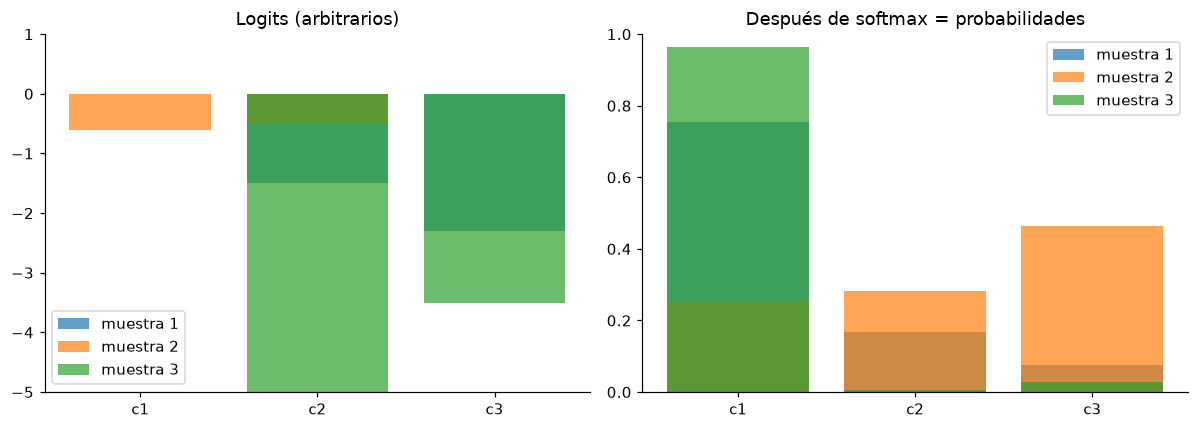

Suma de probabilidades por muestra: [1. 1. 1.]


In [7]:
# Softmax estable + Cross-Entropy con backward integrado

def softmax(z):

    z = z - z.max(axis=1, keepdims=True)  # resto el máx por fila
    e = np.exp(z)                         # exponencial de cada uno 

    return e / e.sum(axis=1, keepdims=True)  # sumat. = 1 

class CrossEntropyLoss:
    def forward(self, logits, y_onehot):
        self.p = softmax(logits)              # probs predichas (B, 10)
        self.y = y_onehot                     # etiq. real (B, 10)

        n = y_onehot.shape[0]                 # tam. del batch
        eps = 1e-12                           # evitamos log(0) = -inf

        return -np.sum(y_onehot * np.log(self.p + eps)) / n # loss promedio solo de la clase correc.

    def backward(self):
          return (self.p - self.y) / self.y.shape[0]


# Visualizacion: softmax convierte logits arbitrarios en probabilidades

logits = np.array([[2.5, 1.0, 0.2], [0.1, 0.2, 0.7], [4.0, -1.0, 0.5]])
probs = softmax(logits)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(3):                       # 3 muestras de ejemplo
    # barras de los logits (corridos al máx para comparar con la escala de la derecha)
    axes[0].bar([0, 1, 2], logits[i] - logits[i].max(), alpha=0.7, label=f"muestra {i+1}")
    # barras de las probabilidades ya normalizadas
    axes[1].bar([0, 1, 2], probs[i], alpha=0.7, label=f"muestra {i+1}")
axes[0].set_xticks([0, 1, 2]); axes[0].set_xticklabels(["c1", "c2", "c3"])
axes[1].set_xticks([0, 1, 2]); axes[1].set_xticklabels(["c1", "c2", "c3"])
axes[0].set_title("Logits (arbitrarios)")
axes[1].set_title("Después de softmax = probabilidades")
axes[0].set_ylim(-5, 1); axes[1].set_ylim(0, 1)
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "softmax.png", dpi=130, bbox_inches="tight")
plt.show()

print("Suma de probabilidades por muestra:", probs.sum(axis=1))

## 2.4. La red completa (forward / backward genéricos)

La red es una **lista de módulos** intercalando capas densas y ReLUs:

```
784 (píxeles) --Dense--> 128 --ReLU--> 64 --Dense--> 10 (logits)
```

La última capa **no lleva activación**: los logits crudos van directo al `CrossEntropyLoss`, que internamente aplica softmax.

In [8]:

# Arquitectura + funciones genéricas forward / backward / predict

def build_model(seed=0):
    """Construye la lista de módulos de la red (784 -> 128 -> 64 -> 10)"""

    return [
        DenseLayer(784, 128, seed=seed, init="he"), 
        ReLU(),                                       
        DenseLayer(128, 64, seed=seed + 1, init="he"),
        ReLU(),                                       
        DenseLayer(64, 10, seed=seed + 2, init="he"), # 10 logits crudos
        ]


def forward(net, x):
    """Recorre las capas hacia adelante encadenando salidas"""
    a = x                        
    for module in net:           
        a = module.forward(a)    # la salida de uno es la entrada del siguiente
    return a                     # logits (B, 10)


def backward(net, dout):
    """Recorre las capas hacia atrás encadenando gradientes"""
    for module in reversed(net):
        dout = module.backward(dout)  # el gradiente fluye de la salida hacia la entrada


def predict(net, x):
    return forward(net, x).argmax(axis=1)  # la clase con logit mayor


def count_params(net):
    return sum(m.W.size + m.b.size for m in net if hasattr(m, "W")) # conteo de pesos y sesgos de todas las capas


net0 = build_model()                                   # creamos la red (pesos al azar)
print("Arquitectura:", [repr(m) for m in net0])        # imprimimos el grafo
print("Parámetros entrenables:", count_params(net0))   # 784*128 + 128*64 + 64*10 + biases

Arquitectura: ['DenseLayer(784 -> 128)', 'ReLU()', 'DenseLayer(128 -> 64)', 'ReLU()', 'DenseLayer(64 -> 10)']
Parámetros entrenables: 109386


In [9]:
# Sanity check: las formas del forward y del backward cierran

# Un mini-batch: 5 imágenes aleatorias de 784 píxeles

x_toy = np.random.default_rng(0).normal(size=(5, 784))
z_toy = forward(net0, x_toy)                       # propagamos
print("forward  (5, 784) -> logits", z_toy.shape)  # debe dar (5, 10) 

ce_toy = CrossEntropyLoss()                        
y_toy = np.eye(10)[[3, 3, 7, 0, 9]]                # clases correctas
loss_toy = ce_toy.forward(z_toy, y_toy)
print(f"loss: {loss_toy:.4f}  (log(1/10)={np.log(1/10):.4f} sería una red que no sabe nada)")  # log(1/10) ref. aprox. para una predic. uniforme

dout_toy = ce_toy.backward()                       # gradiente de la perd. 
backward(net0, dout_toy)                           # propagamos hacia atrás

for m in net0:                                     # inspeccionamos cada capa densa
    if hasattr(m, "W"):
        print(repr(m), "| dW:", m.dW.shape, "| db:", m.db.shape)  

forward  (5, 784) -> logits (5, 10)
loss: 5.4456  (log(1/10)=-2.3026 sería una red que no sabe nada)
DenseLayer(784 -> 128) | dW: (784, 128) | db: (128,)
DenseLayer(128 -> 64) | dW: (128, 64) | db: (64,)
DenseLayer(64 -> 10) | dW: (64, 10) | db: (10,)


### 2.5. Gradient check: ¿es correcto nuestro backprop?

Antes de entrenar nada verificamos que los gradientes **analíticos** del backprop coinciden con los
**numéricos** (diferencias finitas). Son **el mismo número, calculado de dos maneras distintas**:
justamente por eso sirve compararlos.

**1. Gradiente analítico (el que produce el backprop).** Es la derivada exacta de la pérdida respecto a
cada parámetro $\theta$ (cada peso $W_{ij}$, cada bias $b_i$):

$$
\frac{\partial L}{\partial \theta} = \lim_{h \to 0} \frac{L(\theta + h) - L(\theta)}{h}
$$

Evaluar ese límite para las $\sim 10^5$ derivadas de una red real es inabordable a mano. Lo que hacemos es
usar la **regla de la cadena** y propagar el error desde la salida hacia la entrada, capa por capa,
multiplicando jacobianos hasta que cada derivada queda en forma matricial. Eso es el *backpropagation*:
exacto (hasta donde llega el `float64`) y de costo **una sola pasada**. Es el gradiente de la definición,
pero **algebraizado en vez de medido por diferencias**.

**2. Gradiente numérico (diferencias finitas).** No se deriva absolutamente nada: se perturba **un solo**
parámetro en las dos direcciones y se mide cuánto cambia la pérdida:

$$
\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}
\qquad \varepsilon = 10^{-6}
$$

Se llama **diferencia central**, y por eso baja el error de truncamiento de $O(h)$ a $O(h^2)$: se acerca
unas 4 veces más rápido que la diferencia simple $(L(\theta + h) - L(\theta)) / h$. El precio es caro:
cada parámetro cuesta **dos forward passes** (uno con $+\varepsilon$ y otro con $-\varepsilon$), así que
con $P$ parámetros son $2P$ evaluaciones de la red. Es fuerza bruta: lentísimo, pero imposible de
equivocar — si la fórmula de la pérdida está mal, el número sale mal y no hay más que ver.

**3. Por qué compararlos.** El analítico es rápido, pero lo escribimos nosotros: un signo mal puesto o
una transposición de más y sigue siendo *un* gradiente plausible, no un error visible. El numérico es
carísimo y ruidoso, pero es la verdad a la que no le podemos mentir. Si los dos coinciden, es evidencia
muy fuerte de que la fórmula analítica es correcta: dos caminos completamente distintos → mismo número.

El criterio que usamos es el **error relativo**, elemento a elemento:

$$
\text{err} = \frac{\left|g_{\text{num}} - g_{\text{ana}}\right|}{\left|g_{\text{ana}}\right| + 10^{-12}} < 10^{-6}
$$

Con $\varepsilon = 10^{-6}$ el redondeo de la pérdida y el truncamiento de la diferencia se compensan cerca
de $10^{-9}$, así que un error relativo de $10^{-7}$ o $10^{-8}$ es justo lo que esperamos. Si apareciera
$10^{-3}$, o $10^{-1}$ directamente, la fórmula del backprop estaría mal.

> ⚠️ **La trampa clásica:** en $z = 0$ la ReLU tiene una esquina y la derivada no existe, así que la
> definición "por diferencias" y el backprop pueden no coincidir ahí. Por eso el test usa una red chica
> con pesos aleatorios, donde es muy improbable que algún $z$ caiga exactamente en 0.

Es una red diminuta y aleatoria, corriendo una sola pasada: no importa la accuracy, solo los gradientes.

In [10]:

# Gradient check: backprop analítico vs. gradientes numéricos

def check_gradients(seed=7):

    rng = np.random.default_rng(seed)

    net = [
        DenseLayer(3, 5, seed=seed, init="he"),
        ReLU(),
        DenseLayer(5, 5, seed=seed + 1, init="he"),
        ReLU(),
        DenseLayer(5, 4, seed=seed + 2, init="he"),
    ]

    ce = CrossEntropyLoss()
    x = rng.normal(size=(2, 3))              # 2 muestras, 3 features
    y = np.eye(4)[rng.integers(0, 4, size=2)]  # 2 etiq. aleat. de 4 clases one hot

    # Gradiente Analitico (una pasada de backprop) 
    
    z = forward(net, x)            
    _ = ce.forward(z, y)           # pérdida (prob, etiq.)    
    backward(net, ce.backward())   # ce.backward() = grad. loss/logits

    analytic = {}                  # gradientes calculados

    for i, m in enumerate(net): 
        if hasattr(m, "W"):
            analytic[("W", i)] = m.dW.copy()   
            analytic[("b", i)] = m.db.copy()

    # Gradiente Numerico (diferencia central) 

    eps = 1e-6 # perturb. peq.
    max_rel = 0.0                              # mayor error entre ambos met.

    for i, m in enumerate(net):                # por cada capa densa

        if not hasattr(m, "W"):
            continue                           # ignoramos las ReLU

        for pname, arr in (("W", m.W), ("b", m.b)):  # repite el proc. por peso y  luego sesgo

            num = np.zeros_like(arr)                    # matriz llena de 0
            it = np.nditer(arr, flags=["multi_index"])  # ind. de cada elemento
            
            while not it.finished:  # por cada parámetro

                idx = it.multi_index   # posición (i,j)

                old = arr[idx]      # valor original

                # Le sumamos y restamos el eps y calculamos el loss en cada caso 
                arr[idx] = old + eps                    
                z1 = forward(net, x)
                l1 = ce.forward(z1, y)  

                arr[idx] = old - eps                    
                z2 = forward(net, x)
                l2 = ce.forward(z2, y)   

                num[idx] = (l1 - l2) / (2 * eps)         # dif. central = derivada 

                arr[idx] = old                            # restauramos el valor

                it.iternext()                             # siguiente parámetro de la matriz

            rel = np.abs(num - analytic[(pname, i)]) / (np.abs(analytic[(pname, i)]) + 1e-12) # Error relat. 

            max_rel = max(max_rel, rel.max())

            print(f"capa {i:>2} {pname}: error relativo máx = {rel.max():.3e}")

    print(f"\nMax error relativo global: {max_rel:.3e}")
    assert max_rel < 1e-6, "¡El backprop NO coincide con el gradiente numérico!"
    print("✅ Backprop manual verificado contra gradiente numérico. Los gradientes están bien.")
    return max_rel


_ = check_gradients()

capa  0 W: error relativo máx = 6.807e-07
capa  0 b: error relativo máx = 2.355e-10
capa  2 W: error relativo máx = 1.108e-09
capa  2 b: error relativo máx = 7.370e-10
capa  4 W: error relativo máx = 6.597e-09
capa  4 b: error relativo máx = 5.391e-08

Max error relativo global: 6.807e-07
✅ Backprop manual verificado contra gradiente numérico. Los gradientes están bien.


---

# 3. Entrenamiento: backpropagation manual

## La matemática, capa por capa

Definimos la red con capas $l = 1, 2, 3$ y usamos $a^{[l]}$ para la activación de salida de la capa $l$
(siendo $a^{[0]} = X$ la entrada).

**Forward:**

$$
z^{[1]} = X W^{[1]} + b^{[1]}, \quad a^{[1]} = \text{ReLU}(z^{[1]})
$$
$$
z^{[2]} = a^{[1]} W^{[2]} + b^{[2]}, \quad a^{[2]} = \text{ReLU}(z^{[2]})
$$
$$
z^{[3]} = a^{[2]} W^{[3]} + b^{[3]}, \qquad p = \text{softmax}(z^{[3]})
$$
$$
L = -\frac{1}{N}\sum_i \sum_k y_{ik} \log p_{ik}
$$

**Backward (regla de la cadena, de la salida hacia la entrada):**

1. **Última capa.** Usando la simplificación softmax + cross-entropy:
   $$
   \delta^{[3]} = \frac{\partial L}{\partial z^{[3]}} = \frac{p - y}{N}
   $$
   $$
   \frac{\partial L}{\partial W^{[3]}} = {a^{[2]}}^T \delta^{[3]}, \qquad
   \frac{\partial L}{\partial b^{[3]}} = \sum_{\text{batch}} \delta^{[3]}
   $$

2. **ReLU 2.** El gradiente se "filtra": solo pasa donde la entrada de la ReLU era positiva.
   $$
   \delta^{[2]} = 1\left(z^{[2]} > 0\right) \odot \left(\delta^{[3]} {W^{[3]}}^T\right)
   $$

3. **Capa 2.**
   $$
   \frac{\partial L}{\partial W^{[2]}} = {a^{[1]}}^T \delta^{[2]}, \qquad
   \frac{\partial L}{\partial b^{[2]}} = \sum_{\text{batch}} \delta^{[2]}, \qquad
   \frac{\partial L}{\partial a^{[1]}} = \delta^{[2]} {W^{[2]}}^T
   $$

4. **ReLU 1 y Capa 1.** El mismo patrón se repite hacia atrás.

5. **Actualización (gradiente descendente).**
   $$
   W^{[l]} \leftarrow W^{[l]} - \eta \frac{\partial L}{\partial W^{[l]}}, \qquad
   b^{[l]} \leftarrow b^{[l]} - \eta \frac{\partial L}{\partial b^{[l]}}
   $$

### ¿Por qué las derivadas multiplican por `X.T` y por `W.T`?

Mirá la capa densa: $z = aW + b$. El gradiente del batch tiene forma $(B, n_{out})$. Para obtener $\partial L/\partial W$
con forma $(n_{in}, n_{out})$ hay que *premultiplicar* por la entrada transpuesta: $a^T \delta$
→ $(n_{in}, B) \times (B, n_{out})$ ✓.

Y para propagar el error a la capa anterior, hay que *postmultiplicar* por los pesos transpuestos:
$\delta W^T \to (B, n_{out}) \times (n_{out}, n_{in}) = (B, n_{in})$ ✓.
**Los shapes que no cierran a las 2am se arreglan con una transposición… que, además, es la regla de la cadena pura.**

### ¿Por qué mini-batches?

Procesamos **mini-batches de 128** imágenes: las operaciones vectorizadas de NumPy se aprovechan al máximo,
y los gradientes se promedian dentro del batch (estimación con menos ruido que el SGD muestra a muestra).

### ¿Por qué guardamos el mejor modelo y no el último?

Mirá las curvas: el `train_loss` sigue bajando sin parar (terminás en ~0.005, con el train al 99.97%) mientras
la accuracy en validación se **empantana** alrededor de 0.983. Esa es la firma del overfitting: la red dejó de
aprender del MNIST y empezó a memorizar las 55.000 imágenes que le dimos. El modelo del último epoch es,
justamente, el peor candidato.

Por eso en cada epoch miramos el `val_loss` contra el mínimo visto hasta ahora:

$$
L_{\text{val}}^{\,(\text{mejor})} = \min_{1 \leq e \leq \text{epoch}} L_{\text{val}}^{(e)}
$$

y cuando baja más de `min_delta`, guardamos una **copia** de los pesos de ese epoch (copia, no referencia:
`m.W` es un array que en el siguiente batch se vuelve a modificar en el sitio). Cuando termina el
entrenamiento **restauramos esa copia**, así la red que evaluamos es la mejor que vimos y no la última.

`min_delta` importa porque el `val_loss` de esta red **rueda**: entre los epochs 12 y 21 oscila entre 0.071
y 0.077 sin tendencia clara. Sin un umbral, una bajada de 0.0001 —ruido puro— reiniciaría el contador y nos
haría creer que todavía estamos mejorando. Con `min_delta = 0.001` solo cuenta como mejora una bajada real.

Encima va el **early stopping**: si el `val_loss` no mejora durante `patience` epochs seguidos, se corta, porque
seguir entrenando con una validación que ya empeoró es gastar cómputo para empeorar el modelo. Acá `patience = 5`:
el mínimo quedó en el epoch 11 y no se movió en los 5 epochs siguientes, así que ahí cortó.

Ojo con leer esto como un número mágico: es un trade-off. Una paciencia más chica se frena antes de tiempo si
el mejor epoch cae más adelante en otra corrida; una más grande quema epochs que ya no sirven para nada.

> ⚠️ **La trampa de elegir el modelo por validación:** al usar el `val_loss` para elegir el checkpoint, la
> validación deja de ser un termómetro limpio (si la sobreajustás, empieza a "elegir" por ruido). Por eso el
> set de **test se mira una sola vez, al final**, y nunca se usa para decidir nada. Si elegís el modelo
> mirando el accuracy de test, el número que reportás ya está contaminado.

In [11]:
# Funcion de Entrenamiento: mini-batch gradient descent + backprop manual

def train(net, ce, X, Y, X_val, Y_val,
          epochs=30, batch_size=128, lr=0.2, lr_schedule=None, seed=0,
          patience=5, min_delta=1e-3, save_path=None):   # patience=0 desactiva el corte

    rng = np.random.default_rng(seed)    

    if lr_schedule is None:               # si no hay calend. de decay
        lr_schedule = {}

    n = X.shape[0]                        # cant. de muestras de train (55k)
    n_batches = n // batch_size           # batches por epoch (~429)
    y_val_arg = Y_val.argmax(axis=1)      # etiq. de val. (no one-hot)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}  # para las curvas

    def snapshot(modules):                    # "foto" de los pesos: hay que COPIAR, no guardar la ref.
        return [(m.W.copy(), m.b.copy()) for m in modules if hasattr(m, "W")]

    def restore(modules, foto):               # la red vuelve a esa foto
        for m, (W, b) in zip((m for m in modules if hasattr(m, "W")), foto):
            m.W, m.b = W.copy(), b.copy()

    best_val_loss, best_epoch, best_foto = np.inf, 0, None   # el mejor modelo hasta ahora
    sin_mejora = 0                                            # epochs seguidos sin mejorar

    for epoch in range(1, epochs + 1):      

        lr *= lr_schedule.get(epoch, 1.0)       

        perm = rng.permutation(n)               # ind. de las muestras mezclados
        epoch_loss, correct, seen = 0.0, 0, 0   # contadores

        for i in range(n_batches):             

            idx = perm[i * batch_size:(i + 1) * batch_size] # extrae los ind.
            xb, yb = X[idx], Y[idx]             # extrae las img. y etiq. corresp. 

            # Forward
            z = forward(net, xb)                # logits (128, 10)
            loss = ce.forward(z, yb)            # pérdida + guarda p, y

            # Backward
            dout = ce.backward()                # dL/dz = (p - y)/B
            backward(net, dout)                 # disp. de dW y db de todas las capas

            # Actualizacion
            for m in net:                       # act. cada capa a mano
                if hasattr(m, "W"):
                    m.W -= lr * m.dW            # W <- W - lr * dL/dW
                    m.b -= lr * m.db            # b <- b - lr * dL/db

            # acumulamos para las métricas del epoch
            epoch_loss += loss * len(idx)       # pérdida * tamaño del batch
            seen += len(idx)                    # cant. de muestras procesadas

            # comparar el argmax de los logits con la clase real (argmax del one-hot)
            correct += int((z.argmax(axis=1) == yb.argmax(axis=1)).sum())

        #  Validación al final de cada epoch (sin tocar los pesos) 
        z_val = forward(net, X_val)             # solo forward sobre validación
        
        history["train_loss"].append(epoch_loss / seen)   # pérdida promedio
        history["train_acc"].append(correct / seen)       # accuracy train
        val_loss = ce.forward(z_val, Y_val)     # perdida de validacion (sin tocar los pesos)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(float((z_val.argmax(axis=1) == y_val_arg).mean()))  # acc val

        # --- ¿este epoch es el mejor hasta ahora? (elegimos el modelo con el set de validacion) ---
        if val_loss < best_val_loss - min_delta:   # el val_loss bajo lo suficiente
            best_val_loss, best_epoch = val_loss, epoch
            best_foto = snapshot(net)               # guardamos los pesos de este epoch
            sin_mejora = 0
        else:
            sin_mejora += 1                         # epoch sin mejorar

        print(f"epoch {epoch:3d} | loss {history['train_loss'][-1]:.4f} "
              f"| acc train {history['train_acc'][-1]:.4f} "
              f"| acc val {history['val_acc'][-1]:.4f} "
              f"| loss val {val_loss:.4f}"
              + ("   <-- mejor" if best_epoch == epoch else ""))  # marca el mejor epoch

        if patience and sin_mejora >= patience:    # patience>0 = early stopping activado
            print(f"\nEarly stopping en el epoch {epoch}: el val_loss no mejora hace {patience} "
                  f"epochs (mejor: {best_val_loss:.4f} en el epoch {best_epoch}).")
            break

    # --- quedamos con los pesos del MEJOR epoch (el del menor val_loss), no con los del ultimo ---
    if best_foto is not None:
        restore(net, best_foto)
        print(f"\nRed restaurada a los pesos del epoch {best_epoch} "
              f"(mejor val_loss = {best_val_loss:.4f}).")
        if save_path is not None:                  # quedan en disco, por si hay que recargarlos
            Path(save_path).parent.mkdir(parents=True, exist_ok=True)
            np.savez(save_path,
                     best_val_loss=best_val_loss, best_epoch=best_epoch,
                     **{f"W{i}": w for i, (w, _) in enumerate(best_foto)},
                     **{f"b{i}": b for i, (_, b) in enumerate(best_foto)})
            print(f"Mejor modelo guardado en {save_path}")

    history["best_epoch"] = best_epoch            # para reportarlo
    history["best_val_loss"] = best_val_loss
    return history

In [12]:
# Entrenamiento real

net = build_model(seed=42)      # red nueva w aleat.
ce = CrossEntropyLoss()         

hist = train(net, ce,
             X_train, Y_train, X_val, Y_val,
             epochs=30, batch_size=128, lr=0.2,
             lr_schedule={10: 0.5}, seed=0,               # divide el lr a la mitad en el epoch 10
             patience=5,                               # frena si el val_loss no mejora 5 epochs
             save_path=ROOT / "results" / "best_model.npz")   # guarda el mejor modelo en disco


acc_val_del_mejor = hist["val_acc"][hist["best_epoch"] - 1]
print("\nMejor val_loss: {:.4f} (epoch {}) -> esos pesos son los que evaluamos abajo"
      .format(hist["best_val_loss"], hist["best_epoch"]))
print("Accuracy en validación de ese modelo: {:.4f}".format(acc_val_del_mejor))

epoch   1 | loss 0.3720 | acc train 0.8888 | acc val 0.9630 | loss val 0.1428   <-- mejor


epoch   2 | loss 0.1588 | acc train 0.9526 | acc val 0.9684 | loss val 0.1159   <-- mejor


epoch   3 | loss 0.1150 | acc train 0.9660 | acc val 0.9732 | loss val 0.0927   <-- mejor


epoch   4 | loss 0.0896 | acc train 0.9730 | acc val 0.9744 | loss val 0.0942


epoch   5 | loss 0.0726 | acc train 0.9784 | acc val 0.9790 | loss val 0.0807   <-- mejor


...

epoch  12 | loss 0.0185 | acc train 0.9957 | acc val 0.9816 | loss val 0.0742


epoch  13 | loss 0.0168 | acc train 0.9967 | acc val 0.9808 | loss val 0.0714


epoch  14 | loss 0.0150 | acc train 0.9969 | acc val 0.9822 | loss val 0.0745


epoch  15 | loss 0.0135 | acc train 0.9978 | acc val 0.9820 | loss val 0.0733


epoch  16 | loss 0.0123 | acc train 0.9980 | acc val 0.9822 | loss val 0.0730

Early stopping en el epoch 16: el val_loss no mejora hace 5 epochs (mejor: 0.0706 en el epoch 11).

Red restaurada a los pesos del epoch 11 (mejor val_loss = 0.0706).
Mejor modelo guardado en C:\Users\kathe\OneDrive\Desktop\C5DS - Neural_Numpy\results\best_model.npz

Mejor val_loss: 0.0706 (epoch 11) -> esos pesos son los que evaluamos abajo
Accuracy en validación de ese modelo: 0.9816


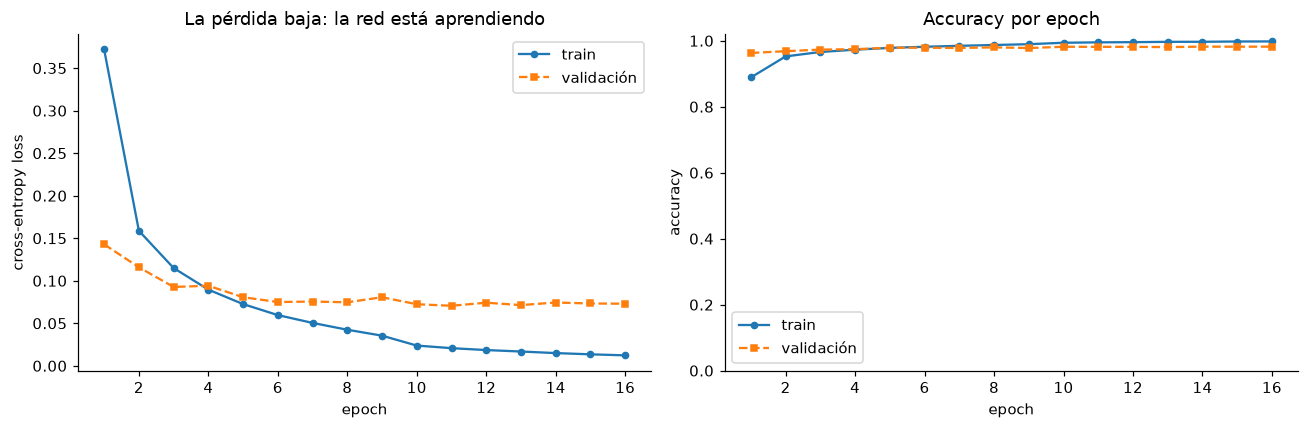

In [13]:
# Curvas de Entrenamiento: loss y accuracy por epoch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))   
epochs = np.arange(1, len(hist["train_loss"]) + 1)  

# Gráfico 1: cross-entropy loss (tiene que bajar) 
axes[0].plot(epochs, hist["train_loss"], "o-", lw=1.5, ms=4, label="train")
axes[0].plot(epochs, hist["val_loss"], "s--", lw=1.5, ms=4, label="validación")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("La pérdida baja: la red está aprendiendo"); axes[0].legend()

# Gráfico 2: accuracy (tiene que subir) 
axes[1].plot(epochs, hist["train_acc"], "o-", lw=1.5, ms=4, label="train")
axes[1].plot(epochs, hist["val_acc"], "s--", lw=1.5, ms=4, label="validación")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy por epoch"); axes[1].legend()
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / "curvas_entrenamiento.png", dpi=130, bbox_inches="tight")
plt.show()

### ¿Hay neuronas muertas?

Una ReLU está **muerta** si su pre-activación es `<= 0` en **todas** las imágenes: nunca se enciende, el gradiente
que le llega es siempre 0, y entonces sus pesos nunca más cambian. Es el problema clásico de la *dying ReLU*, y es
justamente lo que la inicialización He viene a evitar: si los pesos arrancan demasiado chicos, media red nace apagada.

Acá lo medimos sobre **todo el set de train** (el test se mira una sola vez, al final), contando para cada neurona en
qué fracción de las 55.000 imágenes se enciende. Una neurona sana de esta red debería prenderse en un porcentaje
grande de las imágenes.

**Si las hubiera, hay dos formas clásicas de revivirlas:**

1. **Leaky ReLU**: en vez de `max(0, x)`, usar `max(0, x) + 0.01 · min(0, x)`. El gradiente no se corta a cero, así la
   neurona recibe una señal chica y puede volver a prender. Es la solución estándar y la que más se usa.
2. **Reinicializar las muertas**: volver a sortear sus pesos con He y seguir entrenando. Menos elegante, pero es
   literalmente lo que se hizo en el primer AlexNet, y son cuatro líneas.

En este caso **no hace falta ninguna de las dos**: la red entrenada no tiene ninguna neurona muerta. La
inicialización He ya hizo el trabajo, y por eso mirar las activaciones importa tanto como inicializar bien.

In [14]:
# ¿Hay neuronas muertas? Para cada ReLU: en qué fracción del TRAIN se enciende cada neurona

fracs = []                       # un contador de imágenes por cada ReLU de la red

for ini in range(0, len(X_train), 5000):    # de a bloques, para no cargar las 55k de golpe
    a = X_train[ini:ini + 5000]             # un lote de imágenes
    i_relu = 0                              # indice de ReLU DENTRO de este bloque
    for capa in net:
        if hasattr(capa, "W"):
            a = a @ capa.W + capa.b          # z de la capa densa
        else:                                # es una ReLU
            prendidas = (a > 0).sum(axis=0)  # cuántas imágenes prendieron cada neurona
            if len(fracs) == i_relu:         # primera vez que veo esta ReLU
                fracs.append(prendidas.astype(float))
            else:                            # sumo al contador de esta ReLU
                fracs[i_relu] += prendidas
            i_relu += 1
            a = np.maximum(a, 0.0)           # ReLU

for k, f in enumerate(fracs, start=1):
    f = f / len(X_train)                     # de "cuántas imágenes" a "qué porcentaje"
    print(f"ReLU {k}: {int((f == 0).sum()):>3} neuronas MUERTAS | "
          f"{int((f < 0.005).sum()):>3} casi muertas (prenden en <0.5% de las imágenes) | "
          f"activación mediana {np.median(f):.1%}")

print("\n(una neurona sana se enciende en el 5-50% de las imágenes; 0.0% = muerta para siempre)")

ReLU 1:   0 neuronas MUERTAS |   1 casi muertas (prenden en <0.5% de las imágenes) | activación mediana 48.1%
ReLU 2:   0 neuronas MUERTAS |   0 casi muertas (prenden en <0.5% de las imágenes) | activación mediana 62.7%

(una neurona sana se enciende en el 5-50% de las imágenes; 0.0% = muerta para siempre)


---

# 4. Evaluación final

Ahora medimos qué tan bien quedó la red **en datos que nunca vio** (test de MNIST, 10.000 imágenes),
mira ejemplo a ejemplo qué acierta y qué no, y construimos la matriz de confusión a mano con NumPy.

In [15]:

# Accuracy en test (datos que la red nunca vio durante el entrenamiento)

y_pred_test = predict(net, X_test)   # clase predicha para las 10k imágenes
y_true_test = test_labels            # clase real

test_acc = float((y_pred_test == y_true_test).mean())  # fracción de aciertos
print(f"Accuracy en TEST: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Errores: {(y_pred_test != y_true_test).sum()} de {len(y_true_test)}")

Accuracy en TEST: 0.9778  (97.78%)
Errores: 222 de 10000


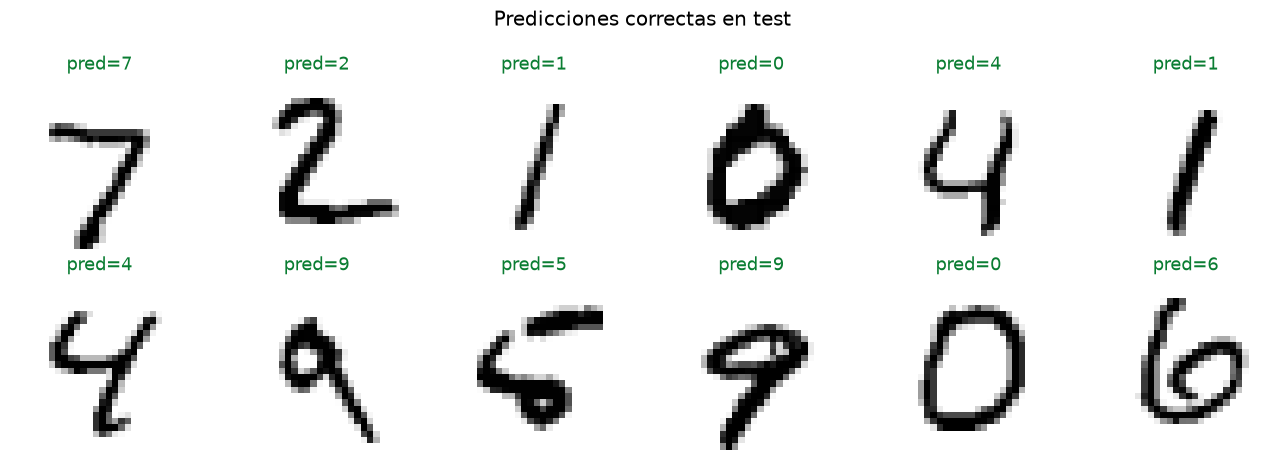

In [16]:

# Predicciones correctas de la red

def plot_predictions(X_img, y_true, y_pred, indices, n_cols=6, correct=True, title=""):
    fig, axes = plt.subplots(2, n_cols, figsize=(2.0 * n_cols, 4.2))
    color = "#0a7d32" if correct else "#c0392b"   # verde = bien, rojo = mal
    for ax, idx in zip(axes.ravel(), indices):   
        ax.imshow(X_img[idx], cmap="gray_r")      
        if correct:
            ax.set_title(f"pred={y_pred[idx]}", color=color, fontsize=12)      # solo la predicción
        else:
            ax.set_title(f"real={y_true[idx]} pred={y_pred[idx]}", color=color, fontsize=10)  # real vs pred
        ax.axis("off")                            # sin ejes
    fig.suptitle(title, y=1.0, fontsize=13)
    plt.tight_layout()
    plt.show()


# posiciones donde el modelo acertó, tomamos las primeras 12
good_idx = np.where(y_pred_test == y_true_test)[0][:12]
plot_predictions(test_images, y_true_test, y_pred_test, good_idx,
                 title="Predicciones correctas en test")

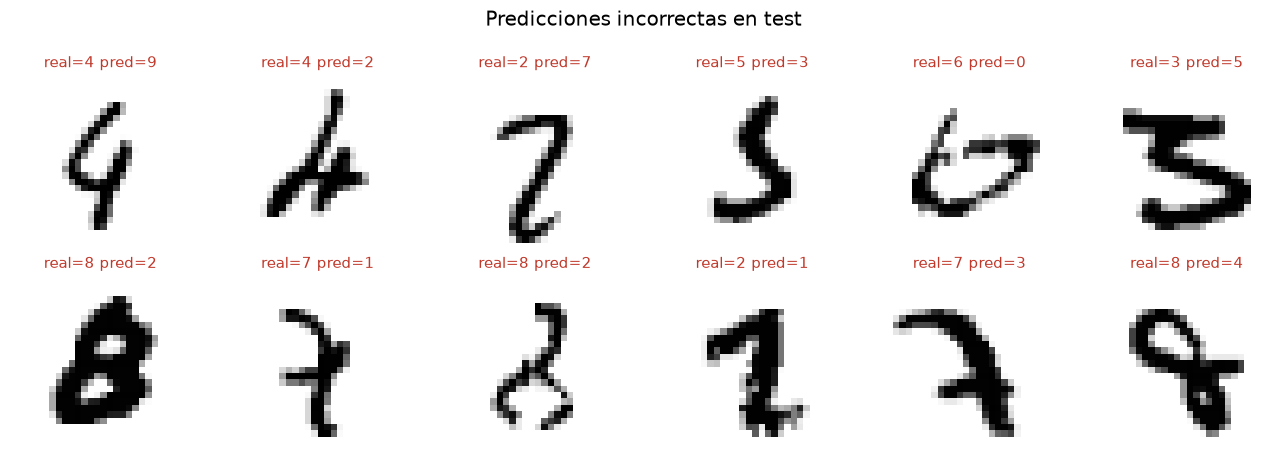

In [17]:
# Predicciones incorrectas ¿qué confunde a la red?

# posiciones donde el modelo se equivocó, tomamos las primeras 12

bad_idx = np.where(y_pred_test != y_true_test)[0][:12]
plot_predictions(test_images, y_true_test, y_pred_test, bad_idx,
                 title="Predicciones incorrectas en test", correct=False)

Matriz de confusión (test):

    pred ->    0    1    2    3    4    5    6    7    8    9
real 0:   967    0    2    1    1    0    3    1    2    3
real 1:     0 1127    1    1    0    1    2    1    2    0
real 2:     4    2 1012    4    3    0    1    4    2    0
real 3:     1    0    4  993    0    2    0    4    3    3
real 4:     2    0    4    1  964    0    1    1    0    9
real 5:     4    0    0   13    3  862    4    0    6    0
real 6:     4    2    0    1   13    5  930    0    3    0
real 7:     1    8    9    4    2    0    1  996    1    6
real 8:     2    0    2    9    3    2    1    5  948    2
real 9:     2    2    0    7   14    1    1    3    0  979


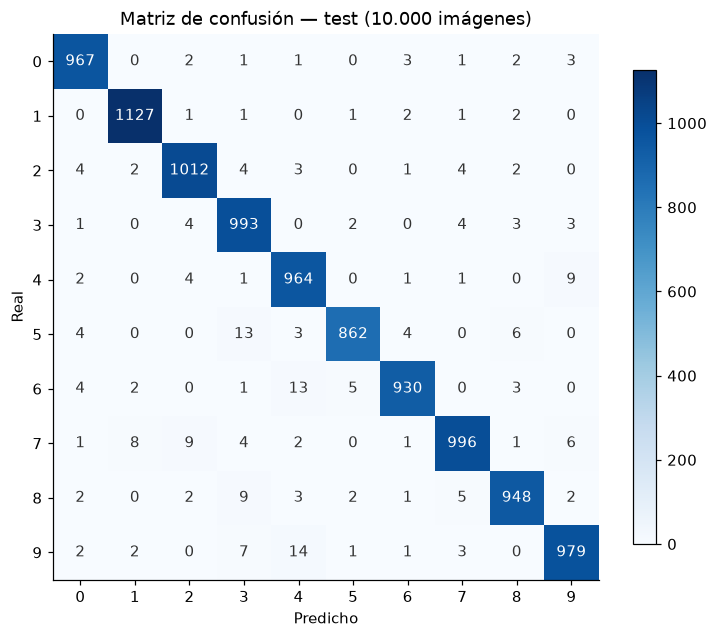

In [18]:
# Matriz de Confusion solo con Numpy

def confusion_matrix_np(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)  
    np.add.at(cm, (y_true, y_pred), 1)
    return cm

cm = confusion_matrix_np(y_true_test, y_pred_test)
print("Matriz de confusión (test):\n")
print("    pred ->", " ".join(f"{i:4d}" for i in range(10)))
for i in range(10):                                  
    print(f"real {i}: ", " ".join(f"{v:4d}" for v in cm[i]))

# heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")                      # celda más oscura = más casos
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — test (10.000 imágenes)")
for i in range(10):                                   # escribimos el número de cada celda
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * 0.6 else "#333")
fig.colorbar(im, shrink=0.8)
plt.savefig(FIG_DIR / "matriz_confusion.png", dpi=130, bbox_inches="tight")
plt.show()

Accuracy por clase (test):
  dígito 0: 0.987  ( 967 bien /  980 total)
  dígito 1: 0.993  (1127 bien / 1135 total)
  dígito 2: 0.981  (1012 bien / 1032 total)
  dígito 3: 0.983  ( 993 bien / 1010 total)
  dígito 4: 0.982  ( 964 bien /  982 total)
  dígito 5: 0.966  ( 862 bien /  892 total)
  dígito 6: 0.971  ( 930 bien /  958 total)
  dígito 7: 0.969  ( 996 bien / 1028 total)
  dígito 8: 0.973  ( 948 bien /  974 total)
  dígito 9: 0.970  ( 979 bien / 1009 total)

Peor clase: dígito 5 (acc 0.966)
Mejor clase: dígito 1 (acc 0.993)

Confusión más frecuente: real=9 predicción=4  ->  14 casos

TOP confusiones (real -> predicción):
  real 9 clasificado como 4: 14 veces
  real 6 clasificado como 4: 13 veces
  real 5 clasificado como 3: 13 veces
  real 8 clasificado como 3: 9 veces


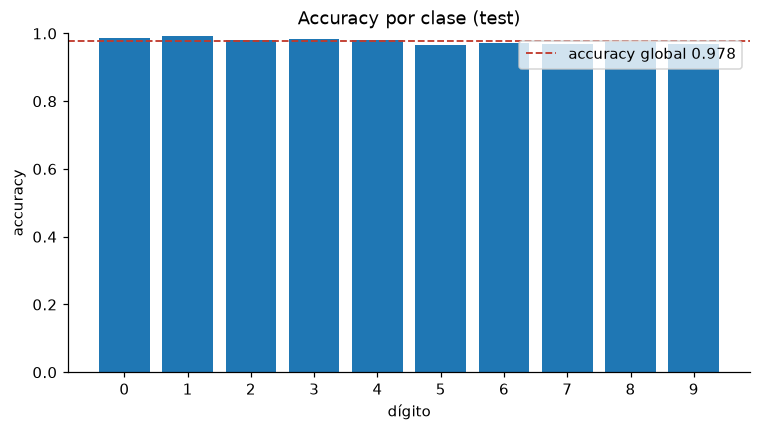

In [19]:

# Analisis por clase: ¿qué dígito confunde más a la red?

# accuracy de cada clase: diagonal / total de reales de esa clase
per_class = np.array([cm[i, i] / cm[i].sum() if cm[i].sum() else 0.0 for i in range(10)])

# copiamos la matriz y anulamos la diagonal -> quedan SOLO los errores
off = cm.copy()
np.fill_diagonal(off, 0)
flat = np.argmax(off)                       # posición del error más grande
r_conf, c_conf = np.unravel_index(flat, off.shape)  # (fila, col) = (real, predicho)

print("Accuracy por clase (test):")
for i in range(10):
    print(f"  dígito {i}: {per_class[i]:.3f}  ({cm[i, i]:>4} bien / {cm[i].sum():>4} total)")

print(f"\nPeor clase: dígito {int(np.argmin(per_class))} (acc {per_class.min():.3f})")
print(f"Mejor clase: dígito {int(np.argmax(per_class))} (acc {per_class.max():.3f})")
print(f"\nConfusión más frecuente: real={r_conf} predicción={c_conf}  ->  {off[r_conf, c_conf]} casos")

# top 4 confusiones (real -> predicción)
top = np.argsort(off.ravel())[::-1][:4]
print("\nTOP confusiones (real -> predicción):")
for t in top:
    r, c = np.unravel_index(t, off.shape)
    print(f"  real {r} clasificado como {c}: {off[r, c]} veces")

# barra de accuracy por clase + línea con el promedio global
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(10), per_class)
ax.axhline(test_acc, color="#c0392b", ls="--", lw=1.2, label=f"accuracy global {test_acc:.3f}")
ax.set_xticks(range(10)); ax.set_ylim(0, 1)
ax.set_xlabel("dígito"); ax.set_ylabel("accuracy")
ax.set_title("Accuracy por clase (test)"); ax.legend()
plt.savefig(FIG_DIR / "accuracy_por_clase.png", dpi=130, bbox_inches="tight")
plt.show()

### ¿Qué dígito confunde más a la red y por qué?

En los resultados salen dos datos distintos, y conviene no mezclarlos:

- **La clase peor clasificada es el `5` (96.6%):** es el dígito con más variantes de trazo (barra de arriba larga o
  corta, arranque con curva o en ángulo). Tanta variedad hace que la red no encuentre un patrón único.
- **El par que más se confunde es `9 → 4` (14 casos):** un `9` cuya panza no cierra del todo *es* un `4` para la red,
  porque comparten el trazo vertical y el "bolsillo". Le siguen `6 → 4` (13), `5 → 3` (13) y `8 → 3` (9).

El patrón se repite en toda la lista: **los errores no son al azar, son formas parecidas.** El `6` y el `4` comparten
la panza; el `5` y el `3` comparten los trazos de arriba; la mitad derecha de un `8` es casi un `3`.

La red aprende *patrones de píxeles*, no "significados": nunca vio un dígito, vio una grilla de números. Por eso
la accuracy por clase no es pareja, y por eso el `1` —que casi no se parece a nada— es la clase más fácil (99.3%).
No es un defecto del código, es lo mismo que le pasa a cualquier humano leyendo letra manuscrita apurada.

---

# 5. Conclusiones — *¿Qué entendiste que antes no entendías?* (celda obligatoria)

Esta celda es la condición para salir de la Matrix.

**Un `.fit()` dejó de ser magia.** Lejos de ser un botón mágico, hoy sé que `.fit()` es — nada más y nada menos —
este bucle de tres pasos repetido `N` veces:

1. **Forward**: multiplicaciones de matrices que propagan la información de la entrada hacia la salida.
2. **Backward**: la regla de la cadena que reparte "cuánta culpa tiene cada peso" del error total.
3. **Update**: cada peso se mueve en la dirección opuesta a su gradiente (bajar la montaña, un pasito por vez).

**Lo que nunca había "visto" y ahora veo:**

- **El truco de `(p - y)`**: la simplificación más hermosa de todo el deep learning. Toda la maquinaria del softmax
  (jacobiano, denominadores compartidos) colapsa en *"probabilidad predicha − etiqueta real"* cuando se combina con
  cross-entropy. A partir de ahí, la derivada de la última capa es trivial.
- **Por qué las dimensiones "se resuelven" con transposiciones**: `a.T @ δ` y `δ @ W.T` no son convenciones arbitrarias:
  son la regla de la cadena escrita en forma matricial. Cuando un shape no cerraba, lo que estaba haciendo mal era
  mezclar `(n_in, n_out)` con `(n_out, n_in)` — y la culpa era mía, no de NumPy.
- **ReLU como "puerta de gradiente"**: no es solo "max(0, x)". Es una compuerta que decide qué neuronas dejan pasar
  señal hacia atrás. El aprendizaje es una *colaboración* entre capas: cada capa ajusta sus pesos mirando el gradiente
  que le pasó la capa de adelante.
- **Por qué la inicialización importa**: con pesos gigantes el gradiente se dispara; con pesos en cero la red no aprende.
  La inicialización He no es decoración: mantiene los gradientes en un rango razonable desde el epoch 0.
- **El overfitting aparece solo**: las curvas train/val se separan, y ahora sé *mirarlas* en vez de esperar un
  número mágico. Y sé qué hacer contra él: quedarme con el epoch de menor `val_loss` (no con el último) y cortar
  el entrenamiento cuando deja de mejorar.
- **Que elegir el "mejor" epoch también sobreajusta**: el `val_loss` del epoch 11 (0.0706) está casi dos desvíos
  estándar por debajo de sus vecinos (0.072 – 0.075), así que buena parte de esa ventaja es ruido de medición y no
  una mejora real. Elegir el mínimo de una curva que rueda es quedarse con el *epoch más afortunado*, no con el mejor
  modelo. Lo correcto sería promediar los pesos de los mejores N epochs; acá no lo hago porque me complica el TP,
  pero ahora sé que el número que reporto tiene ese sesgo.

**La intuición del millón de dólares:** backpropagation es una **cadena de influencias**. Para cada uno de los
~109.000 pesos contesta una sola pregunta: *si muevo este peso un poquito, ¿la pérdida sube o baja, y cuánto?*
Lo hace en una sola pasada hacia atrás, y después mueve cada peso justo al revés. Nada más: bajar una montaña
enorme a pasitos, con 128 ejemplos por paso. Ese es todo el misterio detrás del `.fit()`.
